# Load Packages

In [1]:
push!(LOAD_PATH, pwd()) # put current directory on path
using Revise
using UnPack
#include("ModelHelperFuns.jl")  # load the file
#using .ModelHelperFuns         # bring the module into scope
using CooperativeHuntingPkg
using Plots
default(
    guidefontsize=14,   # controls xlabel, ylabel, title font size
    tickfontsize=12,    # controls axis number labels
    legendfontsize=14,  # controls legend font
    linewidth=2,        # controls default line thickness
    grid = false,        # turns off grid in background
    fontfamily="Computer Modern" # font family that matches latex
)
using BifurcationKit, DifferentialEquations
# pgfplotsx()  # Set PGFPlotsX as the backend # this seems to not work on my computer, or on vscode.
using Measures # helps for adjusting location of axis labels
bif_fig_path = "/Users/taliaborofsky/Documents/Postdoc/Collaborations/CH_GroupFormation/CH_manuscript/FIgures/BifurcationDiagrams/"
using LaTeXStrings


# Basic Parameters

In [2]:
params_base = Dict(
    :α1_of_1 => 0.05,
    :α2_of_1 => 0.95,
    :s1 => 2.0,
    :s2 => 2.0,
    :H1a => 0.0,
    :H2a => 0.0,
    :H2b => 0.0,
    :A1 => 0.6,
    :A2 => 0.5,
    :η2 => 0.6,
    :β2 => 1.0,
    :α2_fun_type => "constant",
    :x_max => 10,
    :Tg => .01,
    :d => 100.0,
    :scale => 5.0
)
u0 = [0.1,0.1, fill(0.1,params_base[:x_max])...]


12-element Vector{Float64}:
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1

# Generate all Figures

below is a summary of the conclusions from all the work done in the rest of the notebook. 

In [3]:
function make_and_save_nice_plots(br_list, fn_string_base)
    pltP = plot_nice_bif(br_list, :P, :scale)
    plot!(ylims=[-0.1,2.8])
    savefig(pltP, bif_fig_path*"p_"*fn_string_base*".pdf")

    pltN1 = plot_nice_bif(br_list, :N1, :scale)
    savefig(pltN1, bif_fig_path*"N1_"*fn_string_base*".pdf")

    pltN2 = plot_nice_bif(br_list, :N2, :scale)
    savefig(pltN2, bif_fig_path*"N2_"*fn_string_base*".pdf")
    pltxbar = plot_nice_bif(br_list, :mean_x, :scale)
    plot!(ylims=[0.9,4.6])
    savefig(pltxbar, bif_fig_path*"meanx_"*fn_string_base*".pdf")

    pltNsum = plot_nice_bif(br_list, :Nsum, :scale)
    savefig(pltNsum, bif_fig_path*"Nsum_"*fn_string_base*".pdf")

    return pltN1
end

make_and_save_nice_plots (generic function with 1 method)

[0.21836024456051684, 0.5067998895455946, 0.419636248904051, 0.1285548153743295, 0.07458386338926003, 0.0002142146055803457, 3.8341055617855367e-7, 5.708900194815018e-10, 7.285575141768388e-13, 8.135376352767739e-16, 8.074908750271609e-19, 7.213395563403075e-22][1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0][0.6767218167740066, 0.0, 0.0029504257084259195, 0.0013129606411649499, 0.002047851230639476, 0.0040662673127916295, 0.006737113395990582, 0.00932505605593189, 0.01106065144745292, 0.011484679994888267, 0.01057803567979227, 0.008666638109609071][0.0, 0.5902982408277694, 0.5167947777867937, 0.0007225713501215632, 6.340415388309203e-7, 6.966072640874746e-8, -8.334918023862401e-8, 6.977046625141343e-8, -4.0082967482086454e-8, 1.513110314204639e-8, -3.391748950814585e-9, 3.433636773556404e-10][0.9998489945252559, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0][0.0, 0.9995805607141938, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

┌ Error: Failure to converge with given tolerance = 1.0e-12.
│ Step = 309
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 0.0001.
│ Stopping continuation at continuation step 309.
└ @ BifurcationKit /Users/taliaborofsky/.julia/packages/BifurcationKit/nhoqA/src/continuation/Contbase.jl:67


[-8.335832888160346e-9, -0.04794786215906275, 0.5441681083439575, 0.2310153728547286, 0.19127293843356868, 0.14361408102195386, 0.09667523225571859, 0.05851179963826994, 0.03204725902582166, 0.015996366243880008, 0.007325659808890005, 0.003096797732027432][0.06899474593672754, -7.776042274743938e-8, 0.5440446360403981, 0.26824694954962347, 0.2710230096757599, 0.13320897076647825, 0.03812937892761376, 0.007340150498150261, 0.001039089548054131, 0.00011473508969619038, 1.029835325964558e-5, 7.745115005012203e-7][-5.360313023583696e-10, 3.2720797883010067e-31, 1.4210697620946213, 0.5048598123142896, 0.2391470013819097, 0.08496114227253732, 0.024147141872478416, 0.005719128827113784, 0.0011610401436123598, 0.0002062398793359334, 3.256458393297892e-5, 4.627654543049044e-6][0.06899262060778144, 2.0586960829605369e-26, 0.544062888253755, 0.26825335302847936, 0.27102294837684904, 0.13320753791549764, 0.03812894883318127, 0.007340113476747977, 0.0010390958080518501, 0.00011473746660366702, 1.02

┌ Error: Failure to converge with given tolerance = 1.0e-12.
│ Step = 398
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 0.0001.
│ Stopping continuation at continuation step 398.
└ @ BifurcationKit /Users/taliaborofsky/.julia/packages/BifurcationKit/nhoqA/src/continuation/Contbase.jl:67
┌ Warning: continue_sp failed for N1_extinct specialpoint 2: ErrorException("Newton failed to converge. Required for the computation of the initial tangent.")
└ @ CooperativeHuntingPkg.MyBifTools /Users/taliaborofsky/Documents/Postdoc/Collaborations/CH_GroupFormation/CH_code/Julia_version/CooperativeHuntingPkg/src/MyBifTools.jl:769


[-8.375378862754632e-27, -0.1045395035038107, 0.12679370343657398, 0.04776597650000137, 0.05519863416368334, 0.07244025200951607, 0.09757316361752043, 0.12932859202215707, 0.16546744294270052, 0.20251605773690937, 0.23614749222961978, 0.26197647924086803][3.7524501509821565e-29, -2.5113403158414572e-11, 0.9473777191671764, 0.22438113582735794, 0.07085789628443283, 0.016782298056745963, 0.00317983505411109, 0.0005020841473143448, 6.795190497128407e-5, 8.047015101493865e-6, 8.470625356711501e-7, 8.024881738976186e-8]

...

[1.0000000000000004, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]Dict{Symbol, Any}(:A1 => 0.6, :H2b => 1.0, :scale => 5.0, :s1 => 2.0, :H1a => 0.0, :H2a => 0.0, :x_max => 10, :α2_of_1 => 0.95, :η2 => 0.6, :α2_fun_type => "constant", :s2 => 2.0, :α1_of_1 => 0.05, :Tg => 0.01, :d => 100.0, :A2 => 0.5, :β2 => 1.0)
[0.5806956966568686, 0.8726891171198384, 0.12013326613846508, 0.07723004323433492, 0.14630196544616336, 0.011493701227469975, 6.911807408171758e-5, 1.5733190187257245e-7, 2.887442554324417e-10, 4.828661403442928e-13, 7.506906285007746e-16, 1.091855779834982e-18][1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0][0.9999999999891476, 0.0, 1.2937264598895544e-8, -3.0142720768337584e-10, 6.121492928256059e-10, -3.0651207404610207e-9, 1.147140459551657e-8, -3.184313611226066e-8, 6.603828892629319e-8, -9.976227086522955e-8, 9.889250953619342e-8, -4.2243112799176975e-8][0.0, 0.9999999999999467, -5.768839246615161e-9, 2.6085791873048875e-8, -6.989993492205568e-8, 1.22

┌ Error: Failure to converge with given tolerance = 1.0e-12.
│ Step = 49
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 0.0001.
│ Stopping continuation at continuation step 49.
└ @ BifurcationKit /Users/taliaborofsky/.julia/packages/BifurcationKit/nhoqA/src/continuation/Contbase.jl:67


, 2.6469779601696886e-23, -1.3234889800848443e-23, -1.3234889800848443e-23, 2.481541837659083e-24, -3.101927297073854e-25][1.0000000000000004, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0][0.0, 1.000000000000031, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0][0.5461540943233633, 0.7780695443970644, 0.2585653866953531, 0.12871127875684535, 0.15535425754748614, 0.0067813252102916655, 2.7568428483702883e-5, 5.2111310856851696e-8, 8.17217002498304e-11, 1.1625764987126642e-13, 1.526881263504144e-16, 1.8644026726936622e-19]

┌ Error: Failure to converge with given tolerance = 1.0e-12.
│ Step = 263
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 0.0001.
│ Stopping continuation at continuation step 263.
└ @ BifurcationKit /Users/taliaborofsky/.julia/packages/BifurcationKit/nhoqA/src/continuation/Contbase.jl:67


[1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0][0.9999999999692455, 0.0, 1.5612188161162062e-8, -2.7185494458030024e-10, 3.480823109207675e-10, -1.8036664685697566e-9, 7.388908108965503e-9, -2.274235351516972e-8, 5.32454515026979e-8, -9.183704036440111e-8, 1.0218919699795765e-7, -4.670772217625599e-8][0.0, 0.9999608792424153, 9.513491358764546e-5, 1.5294352352756437e-7, -9.988233367927968e-8, 1.759428378308842e-7, -2.1240461666360392e-7, 1.7823954531034372e-7, -1.0269713333961166e-7, 3.890664891434243e-8, -8.761827295487191e-9, 8.928013777132411e-10][0.9997401280841285, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0][0.0, 0.9995805607141938, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0][0.5915447449555864, 0.9127775577844294, 0.06365379842684571, 0.052410050028615096, 0.13195325961267843, 0.019323308935211867, 0.00019318997043542586, 5.375044947839022e-7, 1.1057195999363113e-9, 2.0562190315631238e-12, 3.565586588204971e-15, 5.808630909887734e-18][1.0, 1.0, 0.0, 

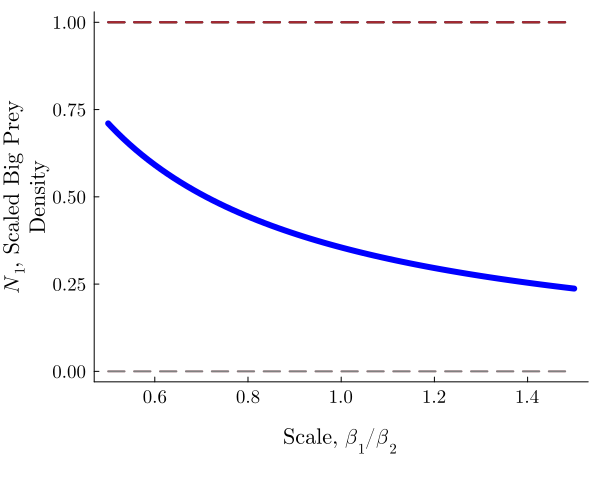

In [5]:
# type I, Scaled

    params = deepcopy(params_base)
    params[:H1a] = params[:H2a] = params[:H2b] = 0
    p_nt = NamedTuple(scale_parameters(params))
    br_list, extra_branches = diagram_2_recursion(
        p_nt; p_min = 1.01, p_max = 8.0, paramkey = :scale, 
        lens = (@optic _.scale), 
        systemfunction = fullsystem_scaled
        );
    plt_nt = make_and_save_nice_plots(br_list, "varyratio_type1")


# type II, vary scale
    params = deepcopy(params_base)
    params[:H1a] = params[:H2a] = 0.0
    params[:H2b] = 1.0
    println(params)
    x_max = params[:x_max]
    u0 = fill(0.1, x_max+2)
    p_nt = NamedTuple(scale_parameters(params))
    br_list, extra_branches = diagram_2_recursion(
        p_nt; paramkey = :scale, p_min = 1.01, p_max = 8.0, lens = (@optic _.scale), 
        systemfunction = fullsystem_scaled); # this should give some warnings because some of the branches don't converge in the extrabranches
    plt_nt2 = make_and_save_nice_plots([br_list..., extra_branches[1:2]...], "varyratio_type2")

# type II, vary η2
    params = deepcopy(params_base)
    params[:H1a] = params[:H2a] = 0.0
    params[:H2b] = 1.0
    params[:scale] = 4.0
    η2_upper = 6.0/7.0
    p_nt = NamedTuple(scale_parameters(params))
    vary_η2_params = (paramkey = :scale, lens = (@optic _.η2), p_min = 0.01, 
p_max = η2_upper);
    # extra branches found to be unnecessary (see work below)
    br_list = do_base_continuations(p_nt, p_nt.x_max; 
            lens = (@optic _.η2), p_min = 0.01, 
            p_max = η2_upper)

    plt_nt_η2 = make_and_save_nice_plots(br_list, "varyeta2_type2")

    
# type II, vary A1
    params = deepcopy(params_base)
    params[:H1a] = params[:H2a] = 0.0
    params[:H2b] = 1.0
    params[:scale] = 6.0
    params[:A1]=0.6
    p_nt = NamedTuple(scale_parameters(params))
    br_list = do_base_continuations(p_nt, p_nt.x_max; lens = (@optic _.A1), 
        p_min = 0.5, p_max = 1.5)
    plt_nt_A1 = make_and_save_nice_plots(br_list, "varyA1_type2")

In [47]:
plt_nt_A1


UndefVarError: UndefVarError: `plt_nt_A1` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [21]:


# type II, vary Tg
    params = deepcopy(params_base)
    params[:H1a] = params[:H2a] = 0.0
    params[:H2b] = 1.0
    params[:scale] = 6.0
    params[:A1]=0.6
    params[:Tg] = 0.1
    params[:Tg_exp] = -3.0
    p_nt = NamedTuple(scale_parameters(params))
    
    br_list = do_base_continuations(p_nt, 5; lens = (@optic _.Tg_exp), 
        p_min = -4.0, p_max = 0.0, systemfunction = fullsystem_scaled_logTg)
        
    plt_meanx = plot_nice_bif_Tg(br_list, :mean_x)
    #plot!(xlabel = "Relative Group Dynamics \nTimescale, "*L"T_g")

    pltN1 = plot_nice_bif_Tg(br_list, :N1)
    #plot!(xlabel = "Relative Group Dynamics \nTimescale, "*L"T_g")


    pltN2 = plot_nice_bif_Tg(br_list, :N2)
    #plot!(xscale = :log)

    pltNsum = plot_nice_bif_Tg(br_list, :Nsum)
    #plot!(xscale = :log)
    #plot!(xlabel = "Relative Group Dynamics \nTimescale, "*L"T_g")


    pltP = plot_nice_bif_Tg(br_list, :P)
    #plot!(xscale = :log)
    #plot!(xlabel = "Relative Group Dynamics \nTimescale, "*L"T_g")

    savefig(plt_meanx, bif_fig_path*"meanx_varyTg_type2.pdf")
    savefig(pltN1, bif_fig_path*"N1_varyTg_type2.pdf")
    savefig(pltN2, bif_fig_path*"N2_varyTg_type2.pdf")
    savefig(pltNsum, bif_fig_path*"Nsum_varyTg_type2.pdf")
    savefig(pltP, bif_fig_path*"p_varyTg_type2.pdf")


    
    

"/Users/taliaborofsky/Documents/CH_GroupFormation/CH_manuscript/FIgures/BifurcationDiagrams/p_varyTg_type2.pdf"

# Type I Fun Response, Scaled

In [4]:
params = deepcopy(params_base)
params[:H1a] = params[:H2a] = params[:H2b] = 0
params[:x_max]=5
p_nt = NamedTuple(scale_parameters(params))
N1_0 =0.4
N2_0 = 0.45
g_out = get_g_equilibria(1.5, N1_0,N2_0, p_nt)
u0 = [N1_0, N2_0, g_out...]

7-element Vector{Float64}:
 0.4
 0.45
 5.6937379281050096e-5
 0.0004900949709303262
 0.4756456383567582
 0.01800586120347013
 5.025589404167059e-7

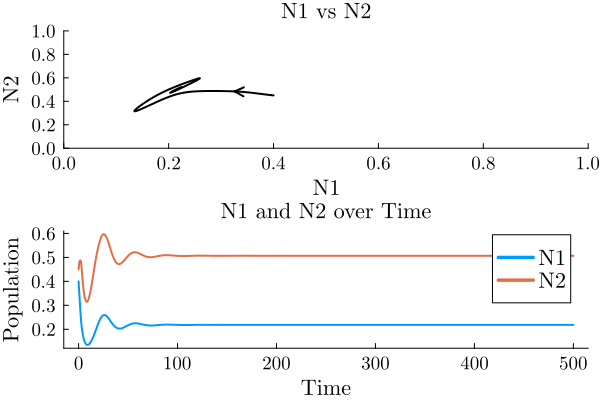

In [5]:

sol, plotN1N2 = simulate_and_plot(u0, p_nt; tf = 500)
display(plotN1N2)

In [6]:
br_list, extra_branches = diagram_2_recursion(p_nt; paramkey = :scale, 
        lens = (@optic _.scale), 
        p_min = 0.1, p_max = 8.0, 
        systemfunction =fullsystem_scaled, 
        dsmax = 0.01)

┌ Warning: continue_sp failed for N1_extinct specialpoint 3: ErrorException("Newton failed to converge. Required for the computation of the initial tangent.")
└ @ CooperativeHuntingPkg.MyBifTools /Users/taliaborofsky/Documents/CH_GroupFormation/CH_code/Julia_version/CooperativeHuntingPkg/src/MyBifTools.jl:684
┌ Warning: continue_sp failed for N1_extinct specialpoint 4: ErrorException("Newton failed to converge. Required for the computation of the initial tangent.")
└ @ CooperativeHuntingPkg.MyBifTools /Users/taliaborofsky/Documents/CH_GroupFormation/CH_code/Julia_version/CooperativeHuntingPkg/src/MyBifTools.jl:684


((coexist =  ┌─ Curve type: EquilibriumCont
 ├─ Number of points: 615
 ├─ Type of vectors: Vector{Float64}
 ├─ Parameter scale starts at 0.8683148017292457, ends at 8.0
 ├─ Algo: PALC
 └─ Special points:

- #  1, endpoint at scale ≈ +0.86671513,                                                                     step =  -1
- #  2,       bp at scale ≈ +1.46221503 ∈ (+1.46221503, +1.46221536), |δp|=3e-07, [converged], δ = (-1,  0), step = 147
- #  3,       bp at scale ≈ +1.55694099 ∈ (+1.55694099, +1.55694258), |δp|=2e-06, [converged], δ = (-1,  0), step = 155
- #  4, endpoint at scale ≈ +8.00000000,                                                                     step = 614
, predator_extinct =  ┌─ Curve type: EquilibriumCont
 ├─ Number of points: 562
 ├─ Type of vectors: Vector{Float64}
 ├─ Parameter scale starts at 0.1, ends at 8.0
 ├─ Algo: PALC
 └─ Special points:

- #  1, endpoint at scale ≈ +0.10000000,                                                                     step = 

hi

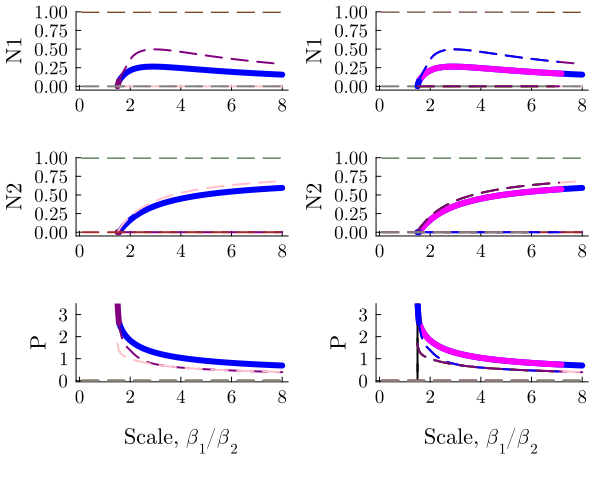

In [7]:
plot_comparison_branches_filtered(
    br_list, [br_list...,extra_branches...], 
    :scale; ymax = 3.5)

hi

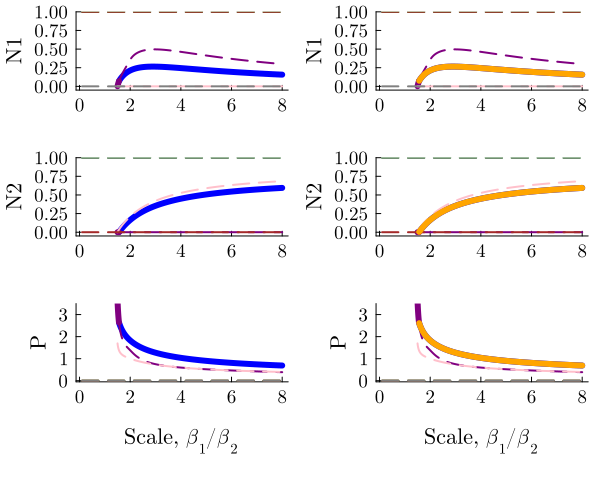

In [8]:
kargs = (
        lens = (@optic _.scale), 
        p_min = 0.1, p_max = 8.0, 
        systemfunction =fullsystem_scaled, 
        dsmax = 0.01
        )

u0 = fill(0.3, p_nt.x_max+2)
g_out = get_g_equilibria(1.5, 0.3, 0.3, p_nt)
u0[3:end] = g_out
u0 = iterate_to_last_pt_scaled(u0, p_nt; tf = 1000)
br_co_2 = do_continuation(u0, p_nt; kargs...)

plot_comparison_branches_filtered(
        [br_list...],[br_list...,br_co_2],
        :scale, ymax = 3.5)

So extra branches unnecessary

## Nice Plots

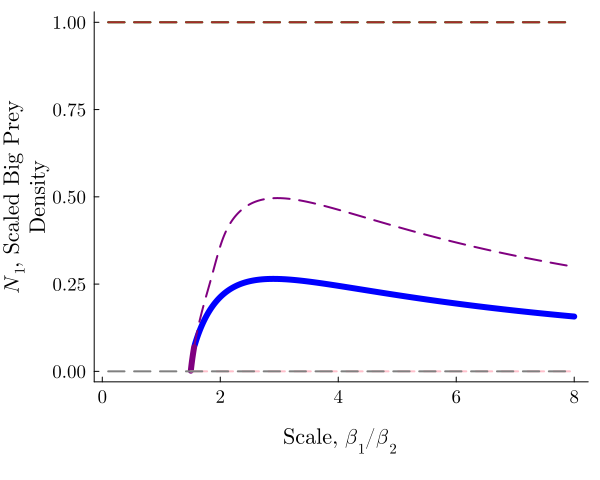

In [10]:
pltN1 = plot_nice_bif(br_list, :N1, :scale)


In [ ]:
pltP = plot_nice_bif(br_list, :P, :scale)
savefig(pltP, bif_fig_path*"p_varyratio_type1.pdf")
pltN1 = plot_nice_bif(br_list, :N1, :scale)
savefig(pltN1, bif_fig_path*"N1_varyratio_type1.pdf")
pltN2 = plot_nice_bif(br_list, :N2, :scale)
savefig(pltN2, bif_fig_path*"N2_varyratio_type1.pdf")
pltxbar = plot_nice_bif(br_list, :mean_x, :scale)
plot!(pltxbar, legend=:right)
savefig(pltxbar, bif_fig_path*"meanx_varyratio_type1.pdf")
pltNsum = plot_nice_bif(br_list, :Nsum, :scale)
savefig(pltNsum, bif_fig_path*"Nsum_varyratio_type1.pdf")

"/Users/taliaborofsky/Documents/CH_GroupFormation/CH_manuscript/FIgures/BifurcationDiagrams/Nsum_varyratio_type1.pdf"

# Type II, Vary Scale

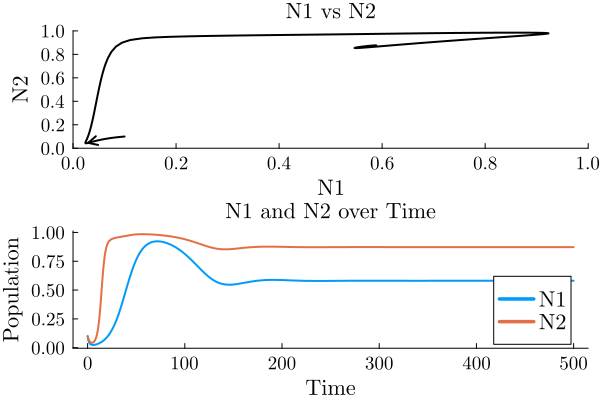

Dict{Symbol, Any}(:A1 => 0.6, :H2b => 1.0, :scale => 5.0, :s1 => 2.0, :H1a => 0.0, :H2a => 0.0, :x_max => 10, :α2_of_1 => 0.95, :η2 => 0.6, :α2_fun_type => "constant", :s2 => 2.0, :α1_of_1 => 0.05, :Tg => 0.01, :d => 100.0, :A2 => 0.5, :β2 => 1.0)


In [61]:
params = deepcopy(params_base)
params[:H1a] = params[:H2a] = 0.0
params[:H2b] = 1.0
println(params)
x_max = params[:x_max]
u0 = fill(0.1, x_max+2)
p_nt = NamedTuple(scale_parameters(params))
sol, plotN1N2 = simulate_and_plot(u0, p_nt; tf = 500)
display(plotN1N2)

┌ Error: Failure to converge with given tolerance = 1.0e-12.
│ Step = 49
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 0.0001.
│ Stopping continuation at continuation step 49.
└ @ BifurcationKit /Users/taliaborofsky/.julia/packages/BifurcationKit/nhoqA/src/continuation/Contbase.jl:67


hi

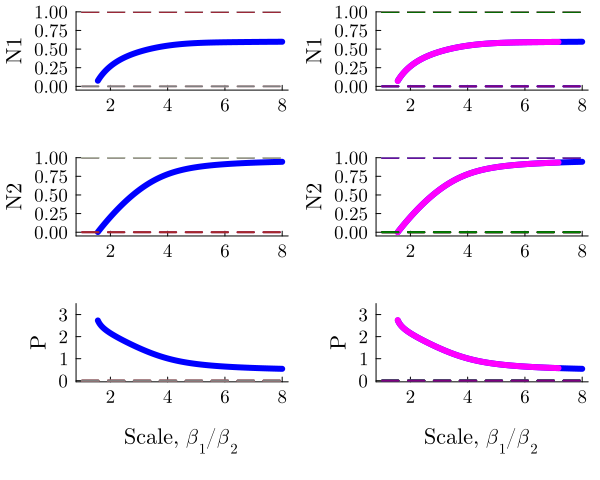

In [17]:
br_list, extra_branches = diagram_2_recursion(
    p_nt, paramkey = :scale; p_min = 1.01, p_max = 8.0, 
    lens = (@optic _.scale), systemfunction = fullsystem_scaled);
#plot_comparison_branches(br_list, extra_branches; ymax = 3.5)
plot_comparison_branches_filtered(br_list, [br_list...,extra_branches...], :scale; ymax = 3.5)

### A few simulations

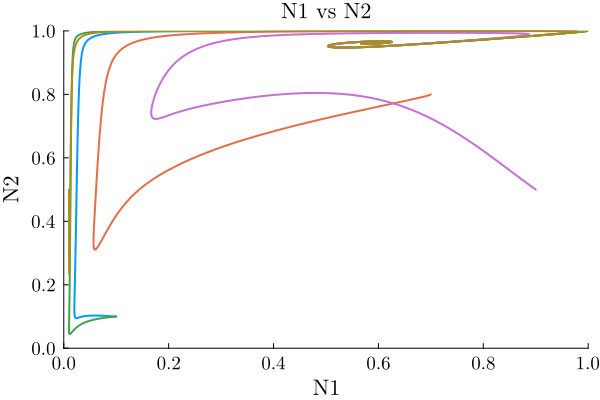

In [ ]:
tf = 1000
tspan = (0.0, tf)
params[:scale ]= 11
p_nt = NamedTuple(scale_parameters(params))
x_max = params[:x_max]
starting_points = [ fill(0.1, x_max + 2),
                    [0.7, 0.8, fill(0.1,x_max)...],
                    [0.1, 0.1, fill(0.2,x_max-2)..., 0.01, 0.01],
                    [0.9, 0.5, 0.01, 1.0, fill(0.01, x_max - 2)... ],
                    [0.01, 0.5, 0.01, 1.0, fill(0.01, x_max - 2)... ]]
plt = plot()
for u0 in starting_points
    prob = ODEProblem(fullsystem_scaled!, u0, tspan, p_nt)
    sol = solve(prob)

    # Extract N1 and N2 from the solution
    N1 = sol[1, :]  # First component of the solution
    N2 = sol[2, :]  # Second component of the solution
    plot!(N1, N2, xlabel="N1", ylabel="N2", title="N1 vs N2", legend=false, 
            xlims = (0,1), ylims = (0,1))
end
display(plt)

## Check Bifurcation Points

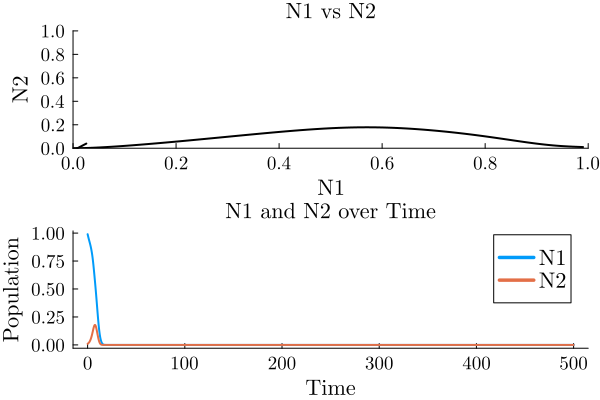

In [32]:
params[:scale] = 1.14
p_nt = NamedTuple(scale_parameters(params))
sol, plotN1N2 = simulate_and_plot([.99, fill(.01,x_max+1)...], p_nt; tf = 500)
display(plotN1N2)

the hopf bifurcation point in the plot is not in a valid range

Checking bifurcation points to see if any of them can be branched from

I assume I'm getting this problem because of the hopf bifurcation being around 0

## Nice Plots 

In [76]:
pltN1 = plot_nice_bif(br_list, :N1, :scale)
savefig(pltN1, bif_fig_path*"N1_varyratio_type2.pdf")
pltN2 = plot_nice_bif(br_list, :N2, :scale)
savefig(pltN2, bif_fig_path*"N2_varyratio_type2.pdf")
pltxbar = plot_nice_bif(br_list, :mean_x, :scale)
savefig(pltxbar, bif_fig_path*"meanx_varyratio_type2.pdf")
pltNsum = plot_nice_bif(br_list, :Nsum, :scale)
savefig(pltNsum, bif_fig_path*"Nsum_varyratio_type2.pdf")

"/Users/taliaborofsky/Documents/CH_GroupFormation/CH_manuscript/FIgures/BifurcationDiagrams/Nsum_varyratio_type2.pdf"

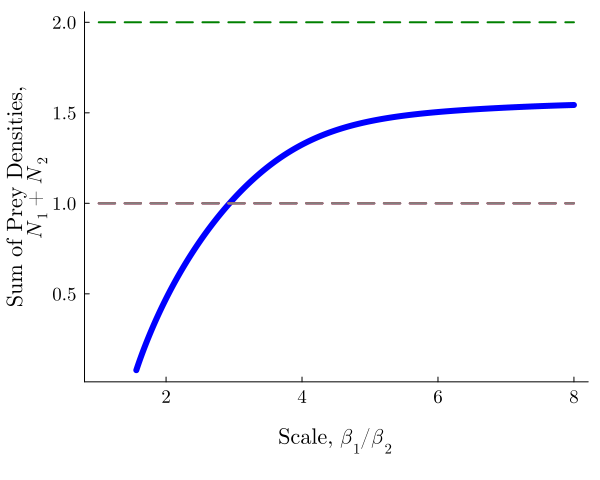

In [33]:
pltNsum = plot_nice_bif(br_list, :Nsum, :scale)


# Type II, vary $\eta_2$

In [38]:
params = deepcopy(params_base)
params[:H1a] = params[:H2a] = 0.0
params[:H2b] = 1.0
params[:scale] = 4.0
println(params)
η2_upper =params[:scale]/(params[:scale]+1)# has to be set so eta1 + eta2 + delta = 1.0. by scaling, eta1 = eta2/(scale). so eta2 (scale+1)/scale < 1 --> eta2 < scale/(scale+1)
x_max = params[:x_max]
u0 = fill(0.1, x_max+2)
p_nt = NamedTuple(scale_parameters(params))
sol, plotN1N2 = simulate_and_plot(u0, p_nt; tf = 500)
#display(plotN1N2)

vary_η2_params = (lens = (@optic _.η2), p_min = 0.01, 
p_max = η2_upper);

Dict{Symbol, Any}(:A1 => 0.6, :H2b => 1.0, :scale => 4.0, :s1 => 2.0, :H1a => 0.0, :H2a => 0.0, :x_max => 10, :α2_of_1 => 0.95, :η2 => 0.6, :α2_fun_type => "constant", :s2 => 2.0, :α1_of_1 => 0.05, :Tg => 0.01, :d => 100.0, :A2 => 0.5, :β2 => 1.0)


[0.5461540943233633, 0.7780695443970644, 0.2585653866953531, 0.12871127875684535, 0.15535425754748614, 0.0067813252102916655, 2.7568428483702883e-5, 5.2111310856851696e-8, 8.17217002498304e-11, 1.1625764987126642e-13, 1.526881263504144e-16, 1.8644026726936622e-19][1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

┌ Error: Failure to converge with given tolerance = 1.0e-12.
│ Step = 263
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 0.0001.
│ Stopping continuation at continuation step 263.
└ @ BifurcationKit /Users/taliaborofsky/.julia/packages/BifurcationKit/nhoqA/src/continuation/Contbase.jl:67


[0.5461540943233633, 0.7780695443970644, 0.2585653866953531, 0.12871127875684535, 0.15535425754748614, 0.0067813252102916655, 2.7568428483702883e-5, 5.2111310856851696e-8, 8.17217002498304e-11, 1.1625764987126642e-13, 1.526881263504144e-16, 1.8644026726936622e-19][1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

┌ Error: Failure to converge with given tolerance = 1.0e-12.
│ Step = 263
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 0.0001.
│ Stopping continuation at continuation step 263.
└ @ BifurcationKit /Users/taliaborofsky/.julia/packages/BifurcationKit/nhoqA/src/continuation/Contbase.jl:67


[0.9999999999692455, 0.0, 1.5612188161162062e-8, -2.7185494458030024e-10, 3.480823109207675e-10, -1.8036664685697566e-9, 7.388908108965503e-9, -2.274235351516972e-8, 5.32454515026979e-8, -9.183704036440111e-8, 1.0218919699795765e-7, -4.670772217625599e-8][0.0, 0.9999608792424153, 9.513491358764546e-5, 1.5294352352756437e-7, -9.988233367927968e-8, 1.759428378308842e-7, -2.1240461666360392e-7, 1.7823954531034372e-7, -1.0269713333961166e-7, 3.890664891434243e-8, -8.761827295487191e-9, 8.928013777132411e-10][0.9997401280841285, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0][0.0, 0.9995805607141938, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]did base continuations
[1.0006809543589539, 1.0043714933745234, -0.01255909456437209, 0.0011582664270961417, -0.0002894181854107077, 1.2348713934786853e-6, 2.779157376016301e-9, 6.204324524689093e-12, 1.300359089924788e-14, 2.561585325175603e-17, 4.752312078904559e-20, 8.321284955267878e-23][1.0000000000000002, 1.0000000000000004, -9.32479

...

[0.5461540943233633, 0.7780695443970644, 0.2585653866953531, 0.12871127875684535, 0.15535425754748614, 0.0067813252102916655, 2.7568428483702883e-5, 5.2111310856851696e-8, 8.17217002498304e-11, 1.1625764987126642e-13, 1.526881263504144e-16, 1.8644026726936622e-19][1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

┌ Error: Failure to converge with given tolerance = 1.0e-12.
│ Step = 263
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 0.0001.
│ Stopping continuation at continuation step 263.
└ @ BifurcationKit /Users/taliaborofsky/.julia/packages/BifurcationKit/nhoqA/src/continuation/Contbase.jl:67


[0.9999999999692455, 0.0, 1.5612188161162062e-8, -2.7185494458030024e-10, 3.480823109207675e-10, -1.8036664685697566e-9, 7.388908108965503e-9, -2.274235351516972e-8, 5.32454515026979e-8, -9.183704036440111e-8, 1.0218919699795765e-7, -4.670772217625599e-8][0.0, 0.9999608792424153, 9.513491358764546e-5, 1.5294352352756437e-7, -9.988233367927968e-8, 1.759428378308842e-7, -2.1240461666360392e-7, 1.7823954531034372e-7, -1.0269713333961166e-7, 3.890664891434243e-8, -8.761827295487191e-9, 8.928013777132411e-10][0.9997401280841285, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0][0.0, 0.9995805607141938, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]did base continuations
[1.0006809543589539, 1.0043714933745234, -0.01255909456437209, 0.0011582664270961417, -0.0002894181854107077, 1.2348713934786853e-6, 2.779157376016301e-9, 6.204324524689093e-12, 1.300359089924788e-14, 2.561585325175603e-17, 4.752312078904559e-20, 8.321284955267878e-23][1.0000000000000002, 1.0000000000000004, -9.32479

┌ Warning: continue_sp failed for coexist specialpoint 3: ErrorException("Newton failed to converge. Required for the computation of the initial tangent.")
└ @ CooperativeHuntingPkg.MyBifTools /Users/taliaborofsky/Documents/Postdoc/Collaborations/CH_GroupFormation/CH_code/Julia_version/CooperativeHuntingPkg/src/MyBifTools.jl:776
┌ Error: Failure to converge with given tolerance = 1.0e-12.
│ Step = 327
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 0.0001.
│ Stopping continuation at continuation step 327.
└ @ BifurcationKit /Users/taliaborofsky/.julia/packages/BifurcationKit/nhoqA/src/continuation/Contbase.jl:67
┌ Warning: continue_sp failed for coexist specialpoint 5: ErrorException("Newton failed to converge. Required for the computation of the initial tangent.")
└ @ CooperativeHuntingPkg.MyBifTools /Users/taliaborofsky/Documents/Postdoc/Collaborations/CH_GroupFormation/CH_code/Julia_ve

[1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0][1.0000000000000897, 0.0, 6.525379230393715e-14, -1.1743889294496376e-14, -7.975136064292088e-15, -7.758965109612829e-15, -4.5095857136526894e-15, -1.1355157219138513e-14, 1.1528672715785667e-14, -3.188815987095781e-14, 3.600747188762684e-14, -2.6102627413532446e-14][0.0, 0.9999999999999855, 3.679537620445551e-14, 4.560995187504701e-17, 5.058332331358136e-20, 4.7357876049750255e-23, -8.338259768186095e-27, 6.597085978182278e-26, -6.483529450875713e-26, 4.477574498034463e-26, -2.1499516503280303e-26, 6.87115104779803e-27][1.0000000000000047, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0][0.0, 1.000000000000031, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]hi

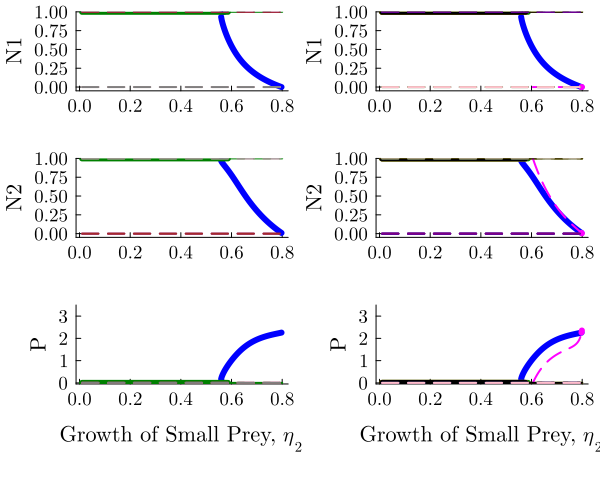

In [39]:
br_list, extra_branches = diagram_2_recursion(
    p_nt, paramkey = :η2; vary_η2_params..., systemfunction = fullsystem_scaled);
#plot_comparison_branches(br_list, extra_branches; ymax = 3.5)
plot_comparison_branches_filtered(
    br_list, [br_list...,extra_branches...], :η2;
     ymax = 3.5, x_max = 5)

In [11]:
.6/.7

0.8571428571428572

## Simulation at $\eta_2 = 0.9$

In [ ]:
plt_meanx = plot_nice_bif(br_list, :mean_x, :η2)
savefig(plt_meanx, bif_fig_path*"meanx_varyeta2_type2.pdf")

pltN1 = plot_nice_bif(br_list, :N1, :η2)
savefig(pltN1, bif_fig_path*"N1_varyeta2_type2.pdf")

pltN2 = plot_nice_bif(br_list, :N2, :η2)
savefig(pltN2, bif_fig_path*"N2_varyeta2_type2.pdf")

pltNsum = plot_nice_bif(br_list, :Nsum, :η2)
savefig(pltNsum, bif_fig_path*"Nsum_varyeta2_type2.pdf")

pltP = plot_nice_bif(br_list, :P, :η2)
savefig(pltP, bif_fig_path*"p_varyeta2_type2.pdf")
#plot_nice_bif(br_list, :g3, :η2)

"/Users/taliaborofsky/Documents/CH_GroupFormation/CH_manuscript/FIgures/BifurcationDiagrams/p_varyeta2_type2.pdf"

# Type II, Vary A1

In [ ]:
params = deepcopy(params_base)
params[:H1a] = params[:H2a] = 0.0
params[:H2b] = 1.0
params[:scale] = 5.0
params[:A1] = 0.6
p_nt = NamedTuple(scale_parameters(params))

br_list, extra_branches = diagram_2_recursion(
    p_nt, ; lens = (@optic _.A1), paramkey = :A1,
    p_min = 0.5, p_max = 3.5, 
    systemfunction = fullsystem_scaled);
#plot_comparison_branches(br_list, extra_branches; ymax = 3.5)
plot_comparison_branches_filtered(
    br_list, [br_list...,extra_branches...], :A1;
     ymax = 2.5, x_max = 5)

## Type II, Vary A2 (scale 5 A1 low at 0.6)

[0.5806956966568686, 0.8726891171198384, 0.12013326613846508, 0.07723004323433492, 0.14630196544616336, 0.011493701227469975, 6.911807408171758e-5, 1.5733190187257245e-7, 2.887442554324417e-10, 4.828661403442928e-13, 7.506906285007746e-16, 1.091855779834982e-18][1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0][0.9999999999891476, 0.0, 1.2937264598895544e-8, -3.0142720768337584e-10, 6.121492928256059e-10, -3.0651207404610207e-9, 1.147140459551657e-8, -3.184313611226066e-8, 6.603828892629319e-8, -9.976227086522955e-8, 9.889250953619342e-8, -4.2243112799176975e-8][0.0, 0.9999999999999467, -5.768839246615161e-9, 2.6085791873048875e-8, -6.989993492205568e-8, 1.229761342444703e-7, -1.4846114329683336e-7, 1.245810935436039e-7, -7.178033370860253e-8, 2.719379649056383e-8, -6.124057074948218e-9, 6.24018294137066e-10][0.9998489945252559, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0][0.0, 0.9995805607141938, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]did base continuatio

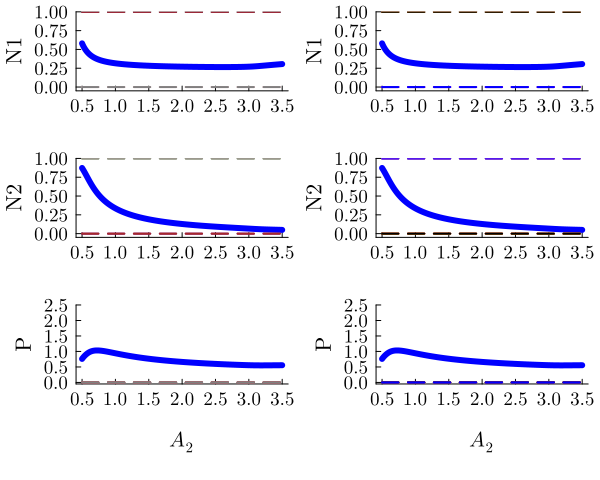

In [64]:
params = deepcopy(params_base)
params[:H1a] = params[:H2a] = 0.0
params[:H2b] = 1.0
params[:scale] = 5.0
params[:A1] = 0.6
p_nt = NamedTuple(scale_parameters(params))

br_list, extra_branches = diagram_2_recursion(
    p_nt, ; lens = (@optic _.A2), paramkey = :A2,
    p_min = 0.5, p_max = 3.5, 
    systemfunction = fullsystem_scaled);
#plot_comparison_branches(br_list, extra_branches; ymax = 3.5)
plot_comparison_branches_filtered(
    br_list, [br_list...,extra_branches...], :A2;
     ymax = 2.5, x_max = 5)

[0.29751705997566574, 0.02207297773764209, 0.03429490969685405, 0.04033709777307694, 0.21126149751409656, 0.1401231610076181, 0.014382682039721486, 0.00038850982570862397, 3.957026320181011e-6, 1.936078775011511e-8, 5.394379245030958e-11, 9.678285237318512e-14][1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0][0.41467899429726224, 0.0, 0.007255958062352686, 0.012559879452318344, 0.039702449066498516, 0.1020195417722833, 0.1193550268225997, 0.043436776588669956, 0.005312757739459021, 0.0002648193921541798, 6.1419012344960255e-6, 1.794596928776657e-7][0.0, 0.0763833785107588, 0.41888028736753075, 0.0005413804009053592, 2.5211277523877664e-7, 6.9595303339487e-8, -8.357275415401018e-8, 6.979346598411697e-8, -3.99781636441143e-8, 1.5034987384968174e-8, -3.353409381836177e-9, 3.3706507131165054e-10][0.9990934107313862, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0][0.0, 0.9995805607141938, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]did base continuations
hi

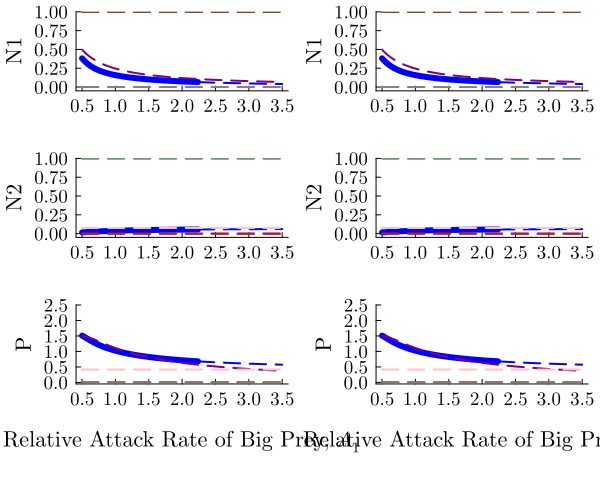

In [96]:
params = deepcopy(params_base)
params[:H1a] = params[:H2a] = 0.0
params[:H2b] = 1.0
params[:scale] = 2.0
params[:A2] = 1.5
p_nt = NamedTuple(scale_parameters(params))

br_list, extra_branches = diagram_2_recursion(
    p_nt, ; lens = (@optic _.A1), paramkey = :A1,
    p_min = 0.5, p_max = 3.5, 
    systemfunction = fullsystem_scaled);
#plot_comparison_branches(br_list, extra_branches; ymax = 3.5)
plot_comparison_branches_filtered(
    br_list, [br_list...,extra_branches...], :A1;
     ymax = 2.5, x_max = 5)

stable_A1_cutoff(br_list, x_max)

In [102]:
stable_A1_cutoff(br_list, x_max)

2.2339999378156037

### Check from different coexistence starting point

In [68]:
function plot_g_heatmap_over_time(sol, x_max)
    gmat = Array(sol)[3:end, :]
    heatmap(
        sol.t,
        1:x_max,
        gmat,
        color = :coolwarm,
        xlabel = "Time",
        ylabel = L"Group size, $x$",
        title = L"Group density, $g(x,t)$",
        colorbar_title = L"g(x,t)",
        yflip = false
    )
end

plot_g_heatmap_over_time (generic function with 1 method)

In [70]:
u0 = fill(0.3, p_nt.x_max+2)
u0[3:end] = get_g_equilibria(1.5,0.3,0.3,p_nt)


10-element Vector{Float64}:
 0.8880257572746629
 0.20579531172817847
 0.06450442575936262
 0.0017089384646945143
 6.9091579125759075e-6
 7.054151829634761e-9
 2.5197144658457805e-12
 3.922136639271296e-16
 3.1068213602452845e-20
 1.4032917781922729e-24

In [44]:
u0 = fill(0.3, p_nt.x_max+2)
u0[3:end] = get_g_equilibria(1.5,0.3,0.3,p_nt)
u0 = iterate_to_last_pt_scaled(u0, p_nt; tf = 1000)
kargs
br_co2 = do_continuation(u0, p_nt; lens = (@optic _.A1),
    p_min = 0.5, p_max = 1.5, 
    systemfunction = fullsystem_scaled)

 ┌─ Curve type: EquilibriumCont
 ├─ Number of points: 75
 ├─ Type of vectors: Vector{Float64}
 ├─ Parameter A1 starts at 0.5, ends at 1.5
 ├─ Algo: PALC
 └─ Special points:

- #  1, endpoint at A1 ≈ +0.50000000,                                                                     step =   0
- #  2, endpoint at A1 ≈ +1.50000000,                                                                     step =  74


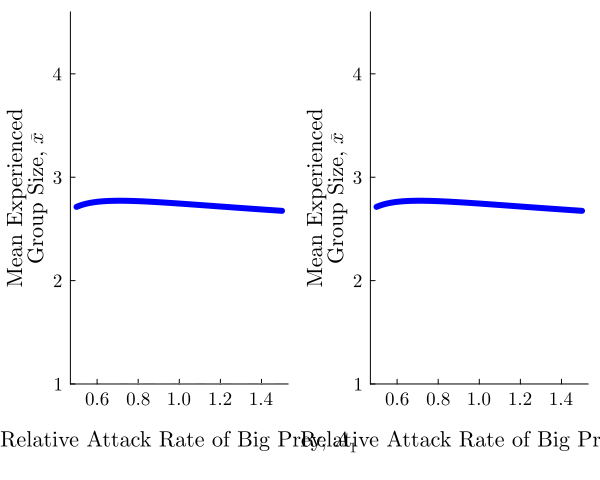

In [45]:
plt1 = plot_nice_bif(br_list, :mean_x, :A1)
plot!(ylims=[1,4.6])

plt2 = plot_nice_bif([br_co2], :mean_x, :A1)
plot!(ylims=[1,4.6])

plot(plt1, plt2)

function stable_A1_cutoff(br_list, x_max; branch_names = (:coexist, :N1_extinct, :N2_extinct))
    stable_params = Float64[]
    
    for branch_name in branch_names
        branch = getproperty(br_list, branch_name)
        out = extract_branch_matrix(branch, x_max)
        if !isempty(out.param)
            append!(stable_params, out.param[out.stable])
        end
    end
    
    stable_params = filter(isfinite, stable_params)
    isempty(stable_params) && return -Inf
    return maximum(stable_params)
end

function minimum_A1_without_stable_equilibrium(
    params_base;
    A2_vec = collect(0.5:0.5:3.5),
    scale_vec = collect(2.0:0.5:5.0),
    A1_min = 0.5,
    A1_max = 2.0,
    branch_names = (:coexist, :N1_extinct, :N2_extinct)
    )
    A1_threshold_mat = fill(NaN, length(scale_vec), length(A2_vec))
    
    for (i, scale_val) in enumerate(scale_vec)
        for (j, A2_val) in enumerate(A2_vec)
            params = deepcopy(params_base)
            params[:H1a] = 0.0
            params[:H2a] = 0.0
            params[:H2b] = 1.0
            params[:scale] = scale_val
            params[:A2] = A2_val
            params[:A1] = A1_min
            
            p_nt = NamedTuple(scale_parameters(params))
            
            try
                br_scan = do_base_continuations(
                    p_nt,
                    p_nt.x_max;
                    lens = (@optic _.A1),
                    p_min = A1_min,
                    p_max = A1_max,
                    systemfunction = fullsystem_scaled
                )

                stable_limit = stable_A1_cutoff(
                    br_scan,
                    p_nt.x_max;
                    branch_names = branch_names
                )

                if stable_limit == -Inf
                    A1_threshold_mat[i, j] = A1_min
                elseif stable_limit < A1_max - 1e-3
                    A1_threshold_mat[i, j] = stable_limit
                end
            catch err
                @warn "Continuation failed for parameter combination" scale_val A2_val err
            end
        end
    end

    return A1_threshold_mat
end

A2_vec = collect(0.5:0.5:3.5)
scale_vec = collect(2.0:0.5:5.0)
A1_min = 0.5
A1_max = 2.0

A1_threshold_mat = minimum_A1_without_stable_equilibrium(
    params_base;
    A2_vec = A2_vec,
    scale_vec = scale_vec,
    A1_min = A1_min,
    A1_max = A1_max
    )

plt_A1_threshold = heatmap(
    A2_vec,
    scale_vec,
    A1_threshold_mat,
    xlabel = L"A_2",
    ylabel = L"\beta_1 / \beta_2",
    title = "Minimum A1 with no stable equilibrium",
    color = :viridis,
    right_margin = 8mm,
    colorbar_title = L"A_1^{crit}"
)

display(plt_A1_threshold)
plt_A1_threshold

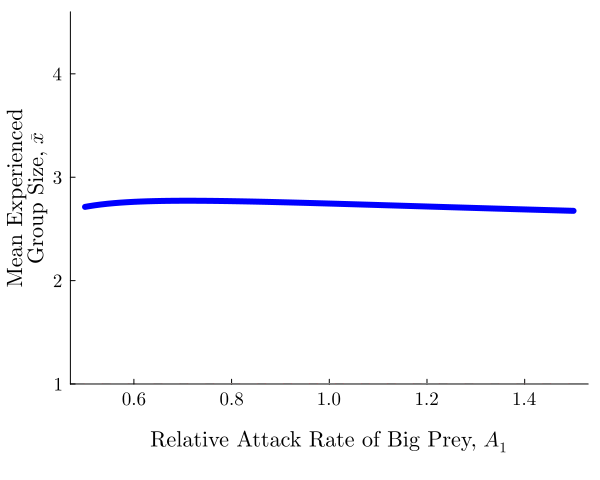

In [28]:
plt_meanx = plot_nice_bif(br_list, :mean_x, :A1)
plot!(ylims=[1,4.6])
#savefig(plt_meanx, bif_fig_path * "meanx_varyA1_type2.pdf")

In [22]:
pltN1 = plot_nice_bif(br_list, :N1, :A1)
savefig(pltN1, bif_fig_path * "N1_varyA1_type2.pdf")


"/Users/taliaborofsky/Documents/CH_GroupFormation/CH_manuscript/FIgures/BifurcationDiagrams/N1_varyA1_type2.pdf"

In [23]:
pltN2 = plot_nice_bif(br_list, :N2, :A1)
savefig(pltN2, bif_fig_path * "N2_varyA1_type2.pdf")



"/Users/taliaborofsky/Documents/CH_GroupFormation/CH_manuscript/FIgures/BifurcationDiagrams/N2_varyA1_type2.pdf"

In [24]:
pltNsum = plot_nice_bif(br_list, :Nsum, :A1)
plot!(ylims=[0,2])
savefig(pltNsum, bif_fig_path * "Nsum_varyA1_type2.pdf")



"/Users/taliaborofsky/Documents/CH_GroupFormation/CH_manuscript/FIgures/BifurcationDiagrams/Nsum_varyA1_type2.pdf"

In [ ]:
pltp = plot_nice_bif(br_list, :P, :A1)
plot!(ylims=[0.0, 2.0])
savefig(pltp, bif_fig_path * "p_varyA1_type2.pdf")


"/Users/taliaborofsky/Documents/CH_GroupFormation/CH_manuscript/FIgures/BifurcationDiagrams/p_varyA1_type2.pdf"

# Type II, Vary Tg

In [49]:
params = deepcopy(params_base)
params[:H1a] = params[:H2a] = 0.0
params[:H2b] = 1.0
params[:scale] = 6.0
params[:A1]=0.6
params[:Tg] = 0.1
params[:Tg_exp] = -3.0
p_nt = NamedTuple(scale_parameters(params))

(A1 = 0.6, η1 = 0.09999999999999999, H2b = 1.0, scale = 6.0, s1 = 2.0, H1a = 0.0, H2a = 0.0, x_max = 10, α2_of_1 = 0.95, η2 = 0.6, α2_fun_type = "constant", s2 = 2.0, α1_of_1 = 0.05, Tg = 0.1, Tg_exp = -3.0, d = 100.0, β1 = 6.0, H1b = 7.199999999999999, A2 = 0.5, β2 = 1.0)

In [50]:
br_list, extra_branches = diagram_2_recursion(p_nt; paramkey = :Tg,
        lens = (@optic _.Tg_exp), 
        p_min = -4.0, p_max = 0.0, 
        systemfunction =fullsystem_scaled_logTg 
        )

((coexist =  ┌─ Curve type: EquilibriumCont
 ├─ Number of points: 286
 ├─ Type of vectors: Vector{Float64}
 ├─ Parameter Tg_exp starts at -4.0, ends at 0.0
 ├─ Algo: PALC
 └─ Special points:

- #  1, endpoint at Tg_exp ≈ -4.00000000,                                                                     step =   0
- #  2, endpoint at Tg_exp ≈ +0.00000000,                                                                     step = 285
, predator_extinct =  ┌─ Curve type: EquilibriumCont
 ├─ Number of points: 286
 ├─ Type of vectors: Vector{Float64}
 ├─ Parameter Tg_exp starts at -4.0, ends at 0.0
 ├─ Algo: PALC
 └─ Special points:

- #  1, endpoint at Tg_exp ≈ -4.00000000,                                                                     step =   0
- #  2,       bp at Tg_exp ≈ -2.83450836 ∈ (-2.83451008, -2.83450836), |δp|=2e-06, [converged], δ = ( 1,  0), step =  84
- #  3, endpoint at Tg_exp ≈ +0.00000000,                                                                     step = 285
, 

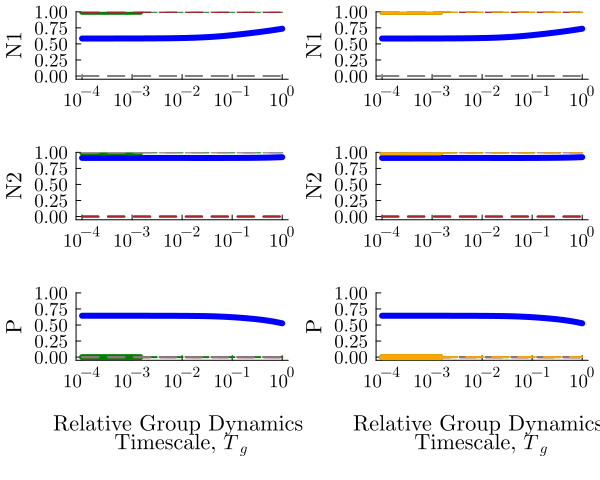

In [53]:
plot_comparison_branches_filtered(br_list, [br_list..., extra_branches...], :Tg; 
    ymax = 1.0, plot_fun = plot_nice_bif_Tg)

0.5841176500185038 0.5841168432757207 0.5841162212512183 0.5841165812377552 0.584117642604937 

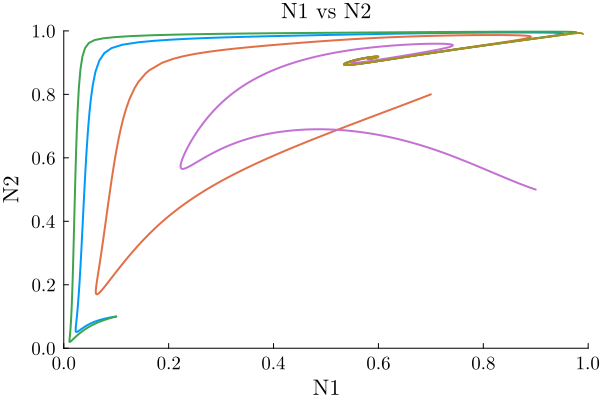

In [60]:
tf = 1000
tspan = (0.0, tf)

params = deepcopy(params_base)
params[:H1a] = params[:H2a] = 0.0
params[:H2b] = 1.0
params[:scale] = 6.0
params[:A1]=0.6
params[:Tg] = 0.0001
p_nt = NamedTuple(scale_parameters(params))
starting_points = [ fill(0.1, x_max + 2),
                    [0.7, 0.8, fill(0.1,x_max)...],
                    [0.1, 0.1, fill(0.2,x_max-2)..., 0.01, 0.01],
                    [0.9, 0.5, 0.01, 1.0, fill(0.01, x_max - 2)...],
                    [0.99, 0.99, fill(0.001,x_max)...]]
plt = plot()
for u0 in starting_points
    prob = ODEProblem(fullsystem_scaled!, u0, tspan, p_nt)
    sol = solve(prob)

    # Extract N1 and N2 from the solution
    N1 = sol[1, :]  # First component of the solution
    N2 = sol[2, :]  # Second component of the solution
    print(N1[end])
    print(" ")
    plot!(N1, N2, xlabel="N1", ylabel="N2", title="N1 vs N2", legend=false, 
            xlims = (0,1), ylims = (0,1))
end
display(plt)

In [73]:
methods(plot_nice_bif_Tg)

# 1 method for generic function "plot_nice_bif_Tg" from CooperativeHuntingPkg.MyBifTools:
 [1] plot_nice_bif_Tg(br_list, y_axis_symbol; colorblind_palette)
     @ ~/Documents/CH_GroupFormation/CH_code/Julia_version/CooperativeHuntingPkg/src/MyBifTools.jl:186

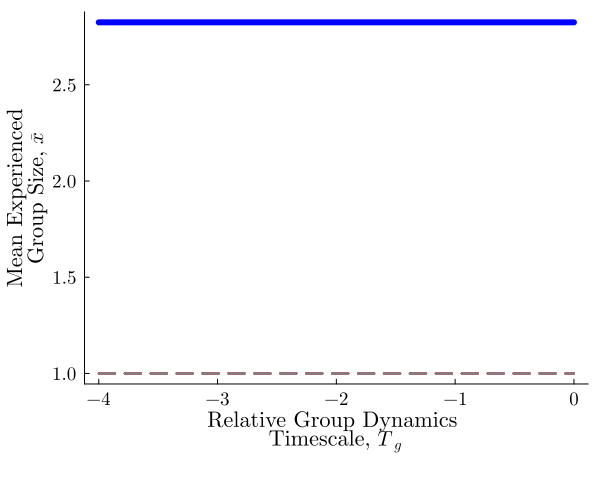

In [21]:
plt_meanx = plot_nice_bif(br_list, :mean_x, :Tg)
#plot!(xscale = :log10)
plot!(xlabel = "Relative Group Dynamics \nTimescale, "*L"T_g")

In [8]:
methods(plot_nice_bif_Tg)

# 1 method for generic function "plot_nice_bif_Tg" from CooperativeHuntingPkg.MyBifTools:
 [1] plot_nice_bif_Tg(br_list, y_axis_symbol; colorblind_palette)
     @ ~/Documents/CH_GroupFormation/CH_code/Julia_version/CooperativeHuntingPkg/src/MyBifTools.jl:304

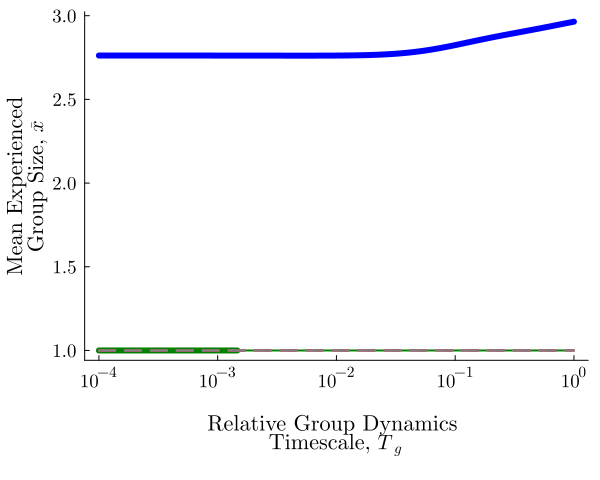

In [9]:
plt_meanx = plot_nice_bif_Tg(br_list, :mean_x)

┌ Warning: No strict ticks found
└ @ PlotUtils /Users/taliaborofsky/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/taliaborofsky/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/taliaborofsky/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/taliaborofsky/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/taliaborofsky/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/taliaborofsky/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/taliaborofsky/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/taliaborofsky/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/taliaborof

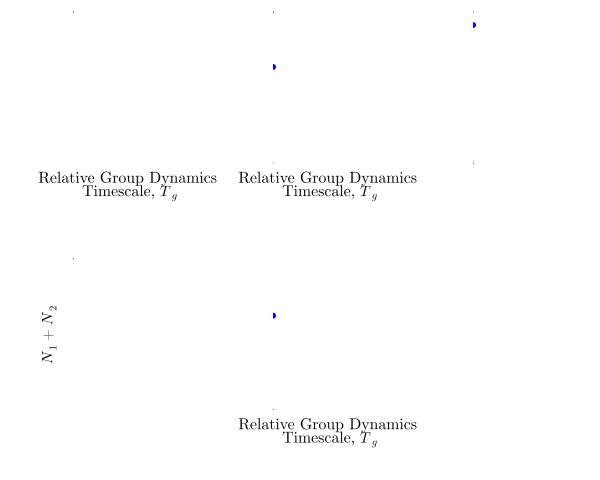

In [ ]:
plt_meanx = plot_nice_bif(br_list, :mean_x, :Tg_exp)
plot!(xscale = :log10)
plot!(xlabel = "Relative Group Dynamics \nTimescale, "*L"T_g")

pltN1 = plot_nice_bif(br_list, :N1, :Tg)
plot!(xscale = :log10)
plot!(xlabel = "Relative Group Dynamics \nTimescale, "*L"T_g")


pltN2 = plot_nice_bif(br_list, :N2, :Tg)
plot!(xscale = :log10)

pltNsum = plot_nice_bif(br_list, :Nsum, :Tg)
plot!(xscale = :log10)
plot!(xlabel = "Relative Group Dynamics \nTimescale, "*L"T_g")


pltP = plot_nice_bif(br_list, :P, :Tg)
plot!(xscale = :log10)
plot!(xlabel = "Relative Group Dynamics \nTimescale, "*L"T_g")


#plot_nice_bif(br_list, :g3, :η2)
pltfull = plot(plt_meanx, pltN1, pltN2, pltNsum, pltP, layout = (2,3),
tickfontsize=8, guidefontsize = 10)

In [5]:
savefig(plt_meanx, bif_fig_path*"meanx_varyTg_type2.pdf")
savefig(pltN1, bif_fig_path*"N1_varyTg_type2.pdf")
savefig(pltN2, bif_fig_path*"N2_varyTg_type2.pdf")
savefig(pltNsum, bif_fig_path*"Nsum_varyTg_type2.pdf")
savefig(pltP, bif_fig_path*"p_varyTg_type2.pdf")

UndefVarError: UndefVarError: `savefig` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

# Breaking input down into segments and plotting stability:

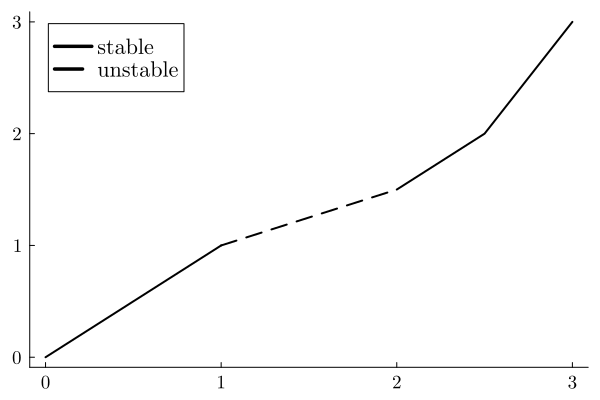

In [ ]:
using Plots


plot()
# Example usage
x_vec = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
y_vec = [0.0, 0.5, 1.0, 1.25, 1.5, 2.0, 3.0]
stability_vec = [true, true, false, false, true, true, false]  # Stability of each point

plt = plot_segments(x_vec, y_vec, stability_vec)
display(plt)

In [16]:
1.5*.5

0.75